# Importing Libraries and Install Envieronment

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install --upgrade transformers

import pandas as pd
import numpy as np
import torch

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer
)

MODEL_PATH = "/content/drive/MyDrive/ABSA_Training_New/IndoBERT_Best_Model"

tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH, local_files_only=True)

model = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH, local_files_only=True)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [ ]:
import pandas as pd

FULL_PATH = "/content/drive/MyDrive/Complete Code ABSA/ABSA_Review_Aspect_Pairs_Raw_New.xlsx"

df = pd.read_excel(FULL_PATH)

print(df.columns.tolist())

['review_id', 'review', 'review_clean', 'rating', 'date', 'thumbs_up', 'aspect', 'aspect_category', 'matched_keywords', 'confidence_score', 'is_gamification_final', 'aspect_verified', 'aspect_changed', 'sentiment', 'notes']


In [ ]:
import pandas as pd


FULL_PATH = "/content/drive/MyDrive/Complete Code ABSA/ABSA_Review_Aspect_Pairs_Raw_New.xlsx"

df = pd.read_excel(FULL_PATH)

print("Original Shape :", df.shape)


df = df.dropna(
    subset=[
        "review_clean",
        "aspect",
        "sentiment"
    ]
)

df = df[
    (df["review_clean"].astype(str).str.strip() != "") &
    (df["aspect"].astype(str).str.strip() != "") &
    (df["sentiment"].astype(str).str.strip() != "")
]

df = df.reset_index(drop=True)

print("Final Shape :", df.shape)

display(df.head())

Original Shape : (8015, 15)
Final Shape : (7961, 15)


,review_id,review,review_clean,rating,date,thumbs_up,aspect,aspect_category,matched_keywords,confidence_score,is_gamification_final,aspect_verified,aspect_changed,sentiment,notes
0,0,saya mendapatkan 380 koin ya bos,saya mendapatkan 380 koin ya bos,5,2025-12-30 23:18:54,0,points,Components,koin,2,Yes,points,No,Positive,NaN
1,2,Alhamdulillah dapat koin 50 semoga lebih besar...,alhamdulillah dapat koin 50 semoga lebih besar...,5,2025-12-30 18:00:08,0,points,Components,koin,2,Yes,points,No,Positive,NaN
2,2,Alhamdulillah dapat koin 50 semoga lebih besar...,alhamdulillah dapat koin 50 semoga lebih besar...,5,2025-12-30 18:00:08,0,resource_acquisition,Mechanics,dapat koin,3,Yes,resource_acquisition,No,Positive,NaN
3,3,cara mudah belanja dan mudah untuk mendapatkan...,cara mudah belanja dan mudah untuk mendapatkan...,5,2025-12-30 16:56:57,0,points,Components,koin,2,Yes,points,No,Positive,NaN
4,5,"saya masih berlangganan shoopie VIP,tp entah k...","saya masih berlangganan shoopie vip,tp entah k...",4,2025-12-30 13:52:04,0,emotions,Dynamics,kesal,2,Yes,emotions,No,Negative,NaN


In [ ]:
from datasets import Dataset

dataset = Dataset.from_pandas(df)

# Create the 'text_input' column in the dataset
# This step was missing from the dataframe processing before dataset creation.
dataset = dataset.map(lambda x: {"text_input": x["aspect"] + " [SEP] " + x["review_clean"]}, batched=False)

def tokenize(batch):

    return tokenizer(
        batch["text_input"],
        truncation=True,
        max_length=128
    )

tokenized_dataset = dataset.map(tokenize, batched=True)

# Remove all columns except the ones directly used by the model
# (input_ids, attention_mask, token_type_ids).
columns_to_keep_for_model = ["input_ids", "attention_mask"]
# Check if tokenizer provides token_type_ids, and if so, add it.
if "token_type_ids" in tokenized_dataset.column_names:
    columns_to_keep_for_model.append("token_type_ids")

columns_to_remove = [col for col in tokenized_dataset.column_names if col not in columns_to_keep_for_model]
tokenized_dataset = tokenized_dataset.remove_columns(columns_to_remove)

# Removed: # Set the dataset format to PyTorch tensors for efficient processing by the Trainer.
# tokenized_dataset.set_format("torch")

# Update 'dataset' variable to reflect the processed dataset
dataset = tokenized_dataset

Map:   0%|          | 0/7961 [00:00<?, ? examples/s]

Map:   0%|          | 0/7961 [00:00<?, ? examples/s]

In [ ]:
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(tokenizer=tokenizer, return_tensors="pt")

trainer = Trainer(
    model=model,
    data_collator=data_collator,
)

pred = trainer.predict(dataset)

prediction = np.argmax(
    pred.predictions,
    axis=1
)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


In [ ]:
!pip install --upgrade torchvision

In [ ]:
import torch
import numpy as np

probabilities = torch.softmax(
    torch.tensor(pred.predictions),
    dim=1
).numpy()

id2label = {
    0: "Negative",
    1: "Neutral",
    2: "Positive"
}

df["predicted_sentiment"] = [
    id2label[i]
    for i in prediction
]

df["prediction_confidence"] = probabilities.max(axis=1)

SAVE_PATH = "/content/drive/MyDrive/Complete Code ABSA/Prediction_IndoBERT_All_AspectPairs.xlsx"

df.to_excel(
    SAVE_PATH,
    index=False
)

print("Saved Successfully!")
print(df.shape)

Saved Successfully!
(7961, 17)


In [ ]:
SAVE_PATH = "/content/drive/MyDrive/ABSA_Training_New/prediction_indobert.csv"

df.to_csv(
    SAVE_PATH,
    index=False
)

print("Saved!")

Saved!


# Sentiment Distribution Gamification Aspects

In [ ]:
overall = (

    df["predicted_sentiment"]

    .value_counts()

    .rename_axis("Sentiment")

    .reset_index(name="Count")

)

overall["Percentage"] = (

    overall["Count"]

    / overall["Count"].sum()

    *100

).round(2)

overall

,Sentiment,Count,Percentage
0,Negative,4856,61.00
1,Positive,2879,36.16
2,Neutral,226,2.84


In [ ]:
aspect_sentiment = (

    pd.crosstab(

        df["aspect"],

        df["predicted_sentiment"]

    )

)

aspect_sentiment

predicted_sentiment,Negative,Neutral,Positive
aspect,,,
achievements,1,1,1
boss_fights,1,0,0
challenges,239,1,12
chance,41,5,4
collections,44,0,20
combat,2,0,0
competition,5,0,7
constraints,16,0,0
content_unlocking,20,0,2


In [ ]:
aspect_percent = (

    pd.crosstab(

        df["aspect"],

        df["predicted_sentiment"],

        normalize="index"

    )*100

).round(2)

aspect_percent

predicted_sentiment,Negative,Neutral,Positive
aspect,,,
achievements,33.33,33.33,33.33
boss_fights,100.00,0.00,0.00
challenges,94.84,0.40,4.76
chance,82.00,10.00,8.00
collections,68.75,0.00,31.25
combat,100.00,0.00,0.00
competition,41.67,0.00,58.33
constraints,100.00,0.00,0.00
content_unlocking,90.91,0.00,9.09


In [ ]:
dominant = aspect_percent.idxmax(axis=1)

dominant = dominant.reset_index()

dominant.columns = [

    "Aspect",

    "Dominant Sentiment"

]

dominant

,Aspect,Dominant Sentiment
0,achievements,Negative
1,boss_fights,Negative
2,challenges,Negative
3,chance,Negative
4,collections,Negative
5,combat,Negative
6,competition,Positive
7,constraints,Negative
8,content_unlocking,Negative
9,cooperation,Negative


In [ ]:
positive_rank = (

    aspect_percent

    .sort_values(

        by="Positive",

        ascending=False

    )

)

positive_rank.head(10)

predicted_sentiment,Negative,Neutral,Positive
aspect,,,
resource_acquisition,35.79,0.92,63.28
competition,41.67,0.00,58.33
cooperation,50.00,0.00,50.00
social_graph,50.00,0.00,50.00
rewards,49.27,3.57,47.16
relationships,54.55,0.00,45.45
emotions,60.00,0.36,39.64
points,57.49,3.05,39.46
teams,57.14,3.57,39.29


In [ ]:
negative_rank = (

    aspect_percent

    .sort_values(

        by="Negative",

        ascending=False

    )

)

negative_rank.head(10)

predicted_sentiment,Negative,Neutral,Positive
aspect,,,
boss_fights,100.00,0.00,0.00
constraints,100.00,0.00,0.00
combat,100.00,0.00,0.00
turns,100.00,0.00,0.00
leaderboards,100.00,0.00,0.00
challenges,94.84,0.40,4.76
content_unlocking,90.91,0.00,9.09
narrative,88.94,3.79,7.27
progression,86.96,0.00,13.04


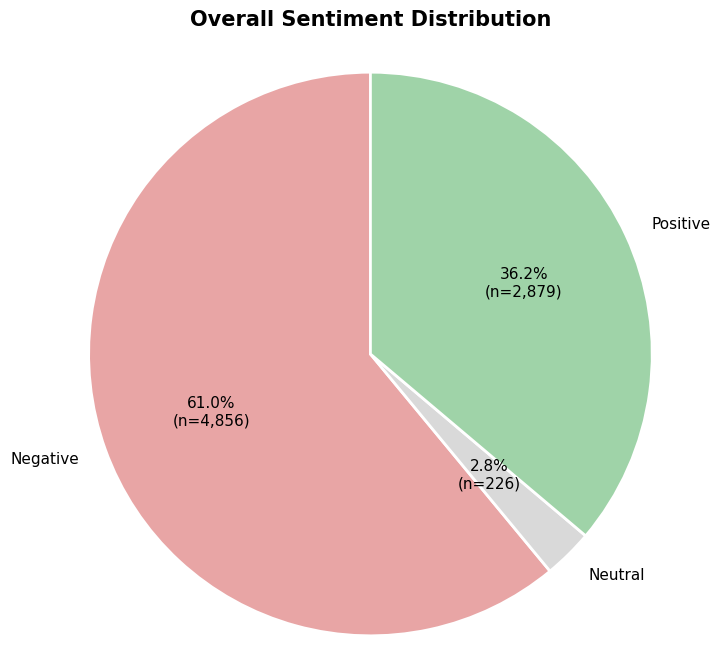

In [ ]:
import matplotlib.pyplot as plt

# Hitung jumlah sentimen
sentiment_counts = df["predicted_sentiment"].value_counts()

# Urutan label
labels = ["Negative", "Neutral", "Positive"]
counts = [sentiment_counts.get(label, 0) for label in labels]

total = sum(counts)

# Warna pastel
colors = [
    "#E8A5A5",   # Soft Red
    "#D9D9D9",   # Soft Gray
    "#9FD3A8"    # Soft Green
]

# Fungsi untuk menampilkan persen + jumlah data
def autopct_format(values):
    def my_format(pct):
        count = int(round(pct * sum(values) / 100.0))
        return f"{pct:.1f}%\n(n={count:,})"
    return my_format

plt.figure(figsize=(8,8))

plt.pie(
    counts,
    labels=labels,
    colors=colors,
    autopct=autopct_format(counts),
    startangle=90,
    textprops={
        "fontsize":11
    },
    wedgeprops={
        "edgecolor":"white",
        "linewidth":2
    }
)

plt.title(
    "Overall Sentiment Distribution",
    fontsize=15,
    fontweight="bold",
    pad=15
)

plt.axis("equal")

plt.show()

<Figure size 1600x600 with 0 Axes>

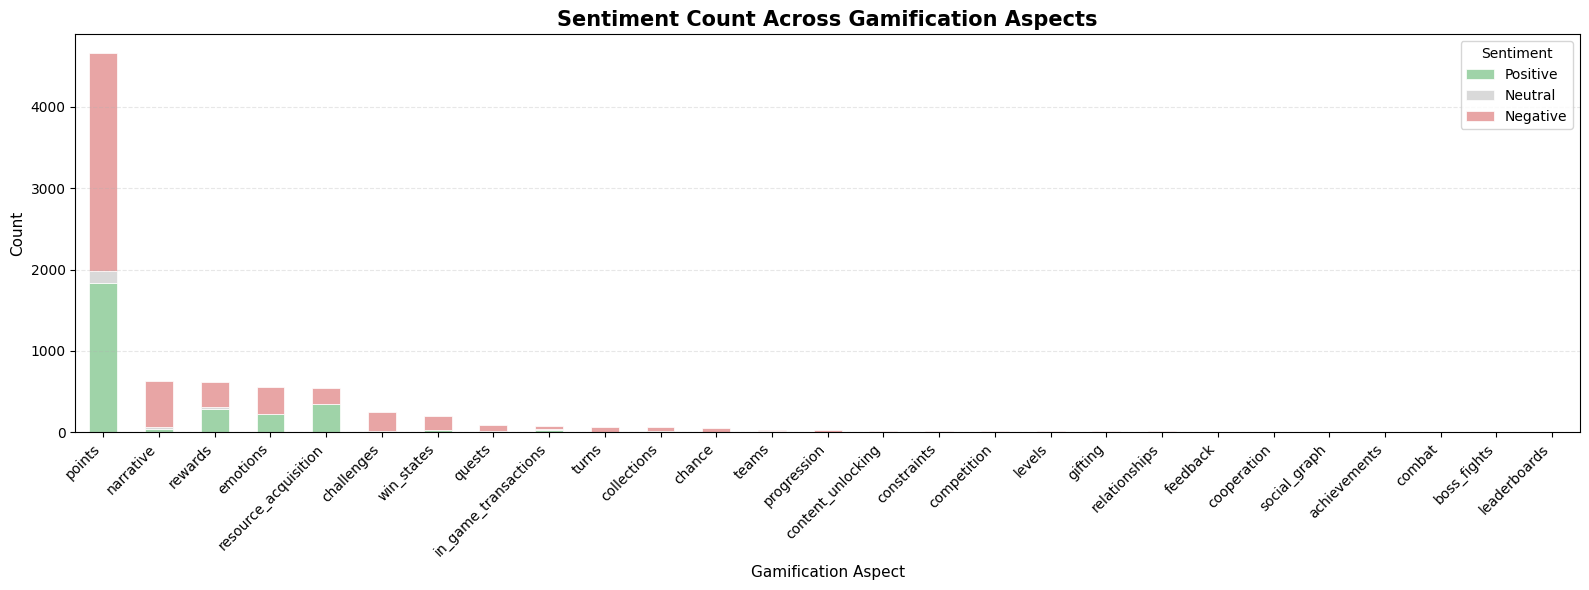

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Hitung jumlah sentiment per aspect
aspect_sentiment = (
    df.groupby(["aspect", "predicted_sentiment"])
      .size()
      .unstack(fill_value=0)
)

# Pastikan urutan kolom konsisten
for col in ["Positive", "Neutral", "Negative"]:
    if col not in aspect_sentiment.columns:
        aspect_sentiment[col] = 0

aspect_sentiment = aspect_sentiment[
    ["Positive", "Neutral", "Negative"]
]

# Urutkan berdasarkan total review
aspect_sentiment = aspect_sentiment.loc[
    aspect_sentiment.sum(axis=1)
    .sort_values(ascending=False)
    .index
]

# Plot
plt.figure(figsize=(16,6))

aspect_sentiment.plot(
    kind="bar",
    stacked=True,
    figsize=(16,6),
    color=[
        "#9FD3A8",   # Positive
        "#D9D9D9",   # Neutral
        "#E8A5A5"    # Negative
    ],
    edgecolor="white",
    linewidth=0.5
)

plt.title(
    "Sentiment Count Across Gamification Aspects",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel(
    "Gamification Aspect",
    fontsize=11
)

plt.ylabel(
    "Count",
    fontsize=11
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.legend(
    title="Sentiment",
    frameon=True
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()

plt.show()

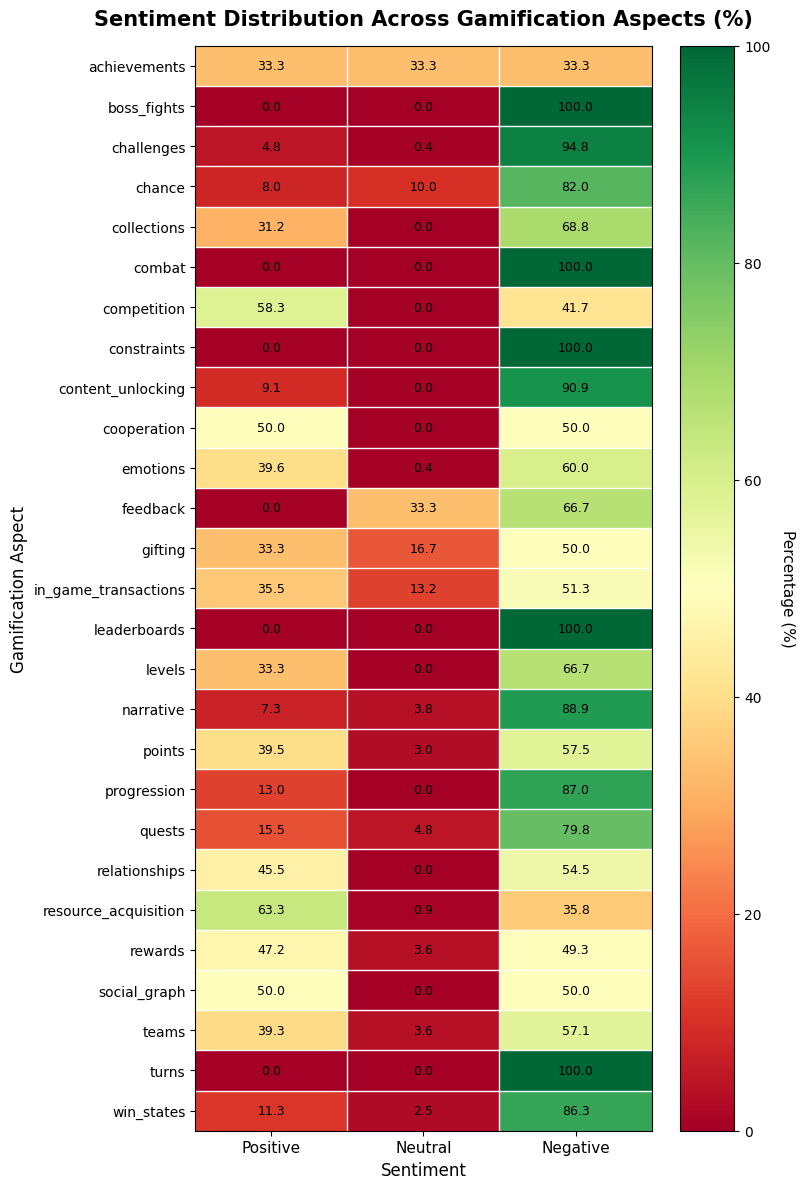

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


heatmap_df = (
    pd.crosstab(
        df["aspect"],
        df["predicted_sentiment"],
        normalize="index"
    ) * 100
).round(1)

# Pastikan urutan kolom
for col in ["Positive", "Neutral", "Negative"]:
    if col not in heatmap_df.columns:
        heatmap_df[col] = 0

heatmap_df = heatmap_df[
    ["Positive", "Neutral", "Negative"]
]


fig, ax = plt.subplots(figsize=(8,12))

im = ax.imshow(
    heatmap_df.values,
    cmap="RdYlGn",
    vmin=0,
    vmax=100,
    aspect="auto"
)

# Axis labels
ax.set_xticks(range(len(heatmap_df.columns)))
ax.set_xticklabels(
    heatmap_df.columns,
    fontsize=11
)

ax.set_yticks(range(len(heatmap_df.index)))
ax.set_yticklabels(
    heatmap_df.index,
    fontsize=10
)

ax.set_xlabel(
    "Sentiment",
    fontsize=12
)

ax.set_ylabel(
    "Gamification Aspect",
    fontsize=12
)

ax.set_title(
    "Sentiment Distribution Across Gamification Aspects (%)",
    fontsize=15,
    fontweight="bold",
    pad=15
)

# Grid putih
ax.set_xticks(
    [x-0.5 for x in range(1,len(heatmap_df.columns))],
    minor=True
)

ax.set_yticks(
    [y-0.5 for y in range(1,len(heatmap_df.index))],
    minor=True
)

ax.grid(
    which="minor",
    color="white",
    linewidth=1
)

ax.tick_params(which="minor", bottom=False, left=False)


for i in range(heatmap_df.shape[0]):
    for j in range(heatmap_df.shape[1]):

        value = heatmap_df.iloc[i,j]

        ax.text(
            j,
            i,
            f"{value:.1f}",
            ha="center",
            va="center",
            fontsize=9,
            color="black"
        )

# Colorbar
cbar = fig.colorbar(im)

cbar.set_label(
    "Percentage (%)",
    rotation=270,
    labelpad=18,
    fontsize=11
)

plt.tight_layout()

plt.show()

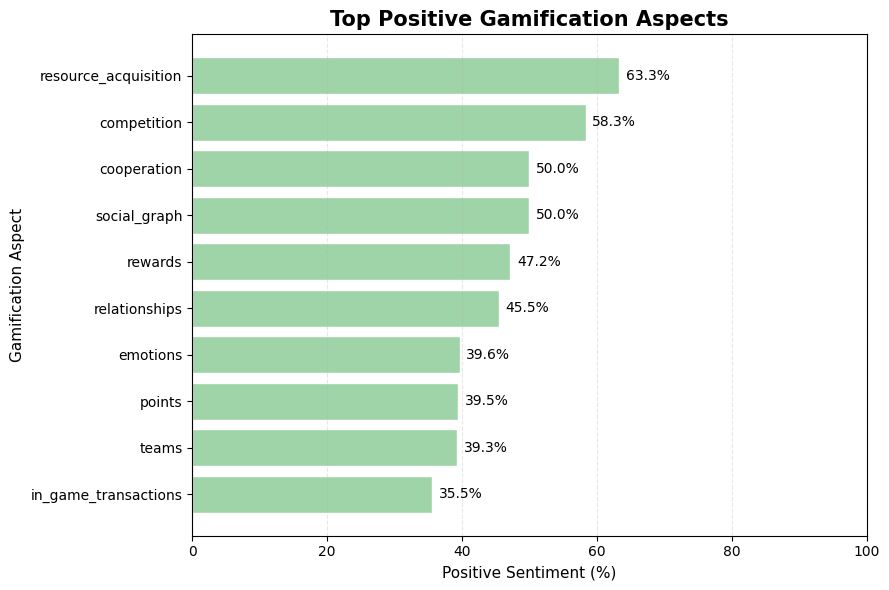

In [ ]:
import matplotlib.pyplot as plt


# Top Positive Gamification Aspects
positive_rank = (
    aspect_percent
    .sort_values(by="Positive", ascending=False)
    .head(10)
)

plt.figure(figsize=(9,6))

bars = plt.barh(
    positive_rank.index,
    positive_rank["Positive"],
    color="#9FD3A8",      # soft green
    edgecolor="white"
)

plt.gca().invert_yaxis()

# Value labels
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 1,
        bar.get_y() + bar.get_height()/2,
        f"{width:.1f}%",
        va="center",
        fontsize=10
    )

plt.xlim(0,100)

plt.xlabel("Positive Sentiment (%)", fontsize=11)
plt.ylabel("Gamification Aspect", fontsize=11)

plt.title(
    "Top Positive Gamification Aspects",
    fontsize=15,
    fontweight="bold"
)

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()

plt.show()

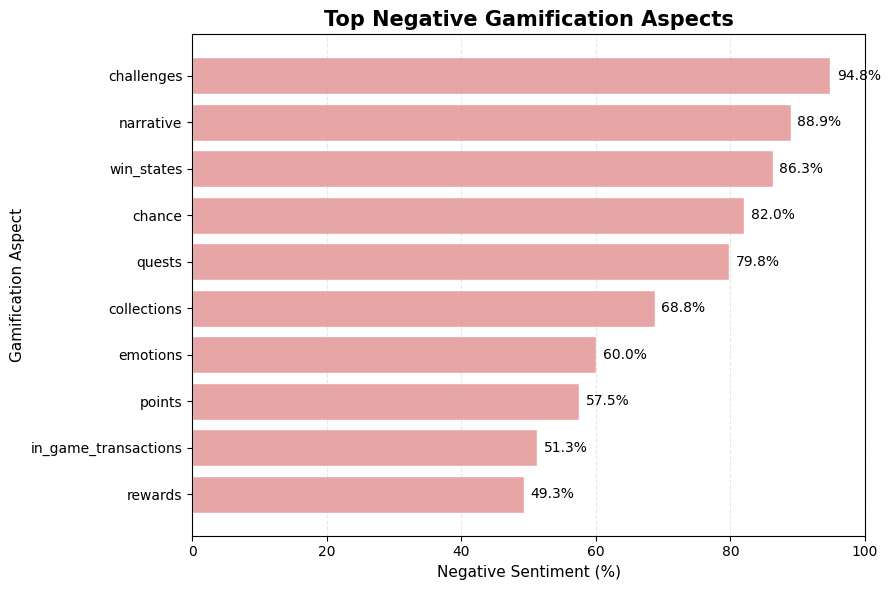

In [ ]:
import matplotlib.pyplot as plt


# Top Negative Gamification Aspects
# (Representative Aspects Only)


# Ranking berdasarkan persentase sentimen negatif
negative_rank = (
    aspect_percent_filtered
    .drop(index=["turns"], errors="ignore")
    .sort_values(by="Negative", ascending=False)
    .head(10)
)

# Plot
plt.figure(figsize=(9,6))

bars = plt.barh(
    negative_rank.index,
    negative_rank["Negative"],
    color="#E8A5A5",      # Soft red
    edgecolor="white"
)

plt.gca().invert_yaxis()

# Label persentase
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 1,
        bar.get_y() + bar.get_height()/2,
        f"{width:.1f}%",
        va="center",
        fontsize=10
    )

plt.xlim(0,100)

plt.xlabel("Negative Sentiment (%)", fontsize=11)
plt.ylabel("Gamification Aspect", fontsize=11)

plt.title(
    "Top Negative Gamification Aspects",
    fontsize=15,
    fontweight="bold"
)

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()

# Purchase Intention Gamification Aspects

In [ ]:
df.columns.tolist()

['review_id',
 'review',
 'review_clean',
 'rating',
 'date',
 'thumbs_up',
 'aspect',
 'aspect_category',
 'matched_keywords',
 'confidence_score',
 'is_gamification_final',
 'aspect_verified',
 'aspect_changed',
 'sentiment',
 'notes',
 'predicted_sentiment',
 'prediction_confidence']

In [ ]:
df = df.rename(columns={

    "review_clean":"text"

})

In [ ]:
df["text"] = (
    df["text"]
    .astype(str)
    .str.lower()
    .str.strip()
)

In [ ]:
positive_purchase = [

    "mau beli",
    "ingin beli",
    "pengen beli",
    "kepengen beli",
    "niat beli",
    "bakal beli",
    "akan beli",
    "jadi beli",
    "langsung beli",

    "checkout",
    "check out",
    "checkout lagi",

    "order",
    "order lagi",

    "pesan",
    "pesan lagi",

    "belanja lagi",

    "repeat order",
    "beli lagi",
    "repeat beli",
    "langganan",

    "masuk keranjang",
    "masukin keranjang",
    "masuk cart",
    "add to cart",

    "borong",
    "borong lagi",

    "buy again",
    "buy more"
]


negative_purchase = [

    "ga jadi beli",
    "gak jadi beli",
    "nggak jadi beli",
    "tidak jadi beli",

    "ga mau beli",
    "gak mau beli",
    "nggak mau beli",
    "tidak mau beli",

    "batal beli",
    "batal checkout",
    "ga jadi checkout",
    "gak jadi checkout",

    "malas beli",
    "males beli",
    "kapok beli",

    "ga jadi order",
    "gak jadi order",

    "ga jadi belanja",
    "gak jadi belanja",

    "hapus aplikasi",
    "uninstall",
    "pindah aplikasi"
]

In [ ]:
import re

def detect_purchase(text):

    if pd.isna(text):
        return "No Purchase Intention"

    text = str(text).lower()

    # negative first
    for phrase in negative_purchase:
        if re.search(r"\b"+re.escape(phrase)+r"\b", text):
            return "Negative Purchase Intention"

    # positive
    for phrase in positive_purchase:
        if re.search(r"\b"+re.escape(phrase)+r"\b", text):
            return "Positive Purchase Intention"

    return "No Purchase Intention"


df["purchase_intention"] = df["text"].apply(detect_purchase)

df["purchase_intention"].value_counts()

,count
purchase_intention,
No Purchase Intention,7683
Positive Purchase Intention,248
Negative Purchase Intention,30


In [ ]:
purchase_summary = (
    df["purchase_intention"]
    .value_counts()
    .rename_axis("Purchase Intention")
    .reset_index(name="Frequency")
)

purchase_summary["Percentage"] = (
    purchase_summary["Frequency"] /
    purchase_summary["Frequency"].sum()*100
).round(2)

purchase_summary

,Purchase Intention,Frequency,Percentage
0,No Purchase Intention,7683,96.51
1,Positive Purchase Intention,248,3.12
2,Negative Purchase Intention,30,0.38


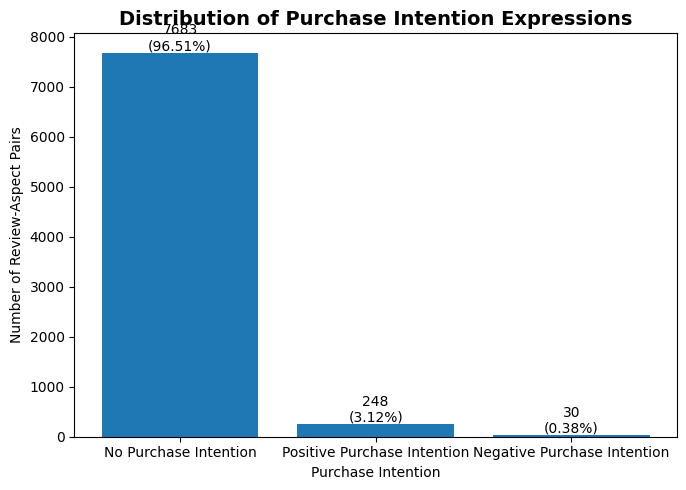

In [ ]:
import matplotlib.pyplot as plt

# Purchase Intention Distribution

plot_df = purchase_summary.copy()

plt.figure(figsize=(7,5))

bars = plt.bar(
    plot_df["Purchase Intention"],
    plot_df["Frequency"]
)

plt.ylabel("Number of Review-Aspect Pairs")
plt.xlabel("Purchase Intention")
plt.title(
    "Distribution of Purchase Intention Expressions",
    fontsize=14,
    fontweight="bold"
)

# Tambahkan value + percentage
for bar, (_, row) in zip(bars, plot_df.iterrows()):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 50,
        f'{row["Frequency"]}\n({row["Percentage"]:.2f}%)',
        ha='center',
        fontsize=10
    )

plt.tight_layout()

plt.savefig(
    "Figure_30_Purchase_Intention_Distribution.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

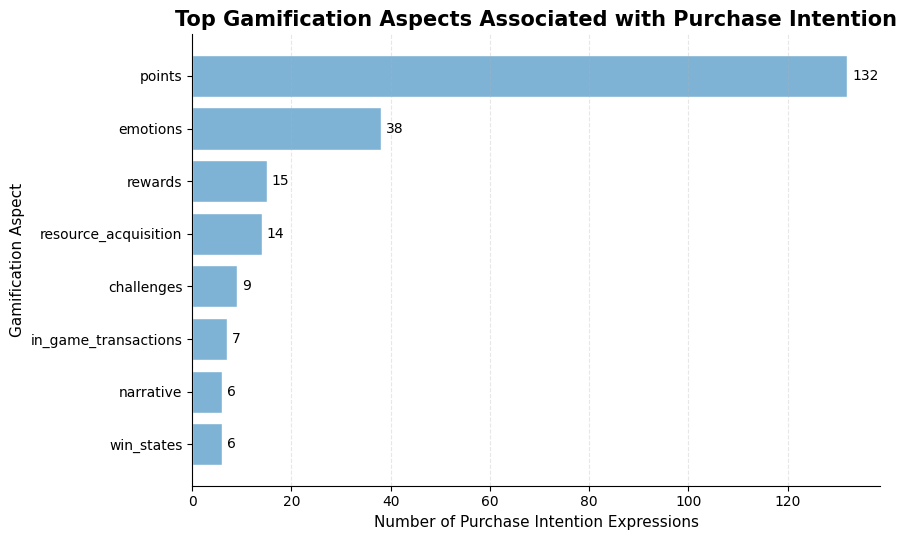

In [ ]:
import matplotlib.pyplot as plt

# Hitung jumlah niat beli positif per aspek
purchase_by_aspect = (
    df[df["purchase_intention"] == "Positive Purchase Intention"]
    .groupby("aspect")
    .size()
    .rename("Purchase Intention Count")
)

# Top aspect dengan purchase intention terbanyak
top_purchase = (
    purchase_by_aspect
    .sort_values(ascending=False)
    .head(8)
)

plt.figure(figsize=(9,5.5))

bars = plt.barh(
    top_purchase.index,
    top_purchase.values,
    color="#7FB3D5",       # soft blue
    edgecolor="white"
)

plt.gca().invert_yaxis()

# Tambahkan label jumlah
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 1,
        bar.get_y() + bar.get_height()/2,
        f"{int(width)}",
        va="center",
        fontsize=10
    )

plt.xlabel("Number of Purchase Intention Expressions", fontsize=11)
plt.ylabel("Gamification Aspect", fontsize=11)

plt.title(
    "Top Gamification Aspects Associated with Purchase Intention",
    fontsize=15,
    fontweight="bold"
)

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

# Hilangkan frame atas & kanan
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

# Kalau mau disimpan
# plt.savefig("Figure_32_Top_Purchase_Intention_Aspects.png",
#             dpi=300,
#             bbox_inches="tight")

plt.show()

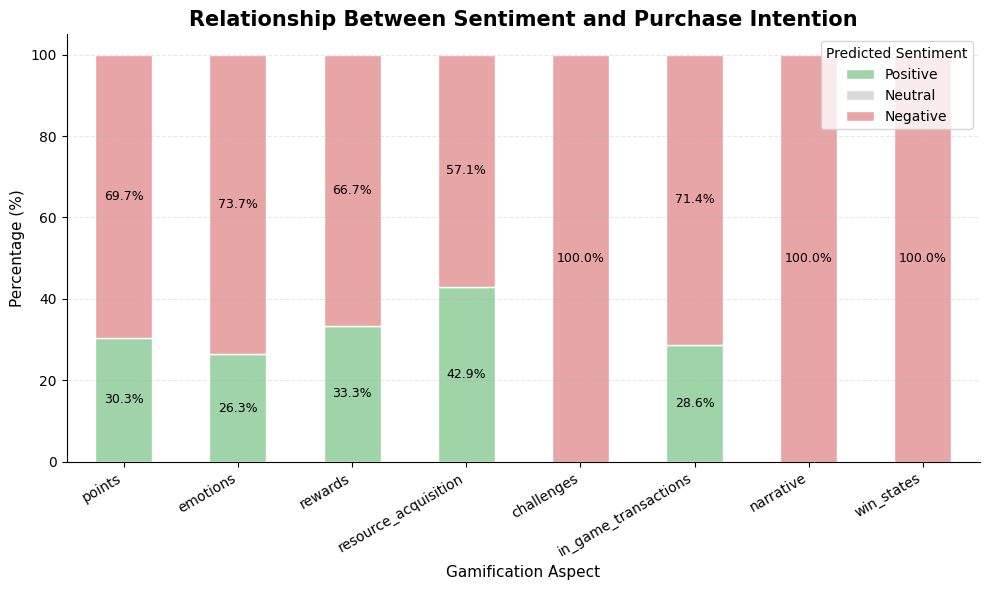

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


# Relationship Between Sentiment and Purchase Intention


# Filter review yang memiliki purchase intention
pi_df = df[df["purchase_intention"] == "Positive Purchase Intention"].copy()

# Crosstab Aspect × Predicted Sentiment
relationship = pd.crosstab(
    pi_df["aspect"],
    pi_df["predicted_sentiment"]
)

# Pastikan semua kolom sentiment tersedia
for col in ["Positive", "Neutral", "Negative"]:
    if col not in relationship.columns:
        relationship[col] = 0

relationship = relationship[["Positive", "Neutral", "Negative"]]

# Ambil Top 8 aspect dengan purchase intention terbanyak
top8 = relationship.sum(axis=1).sort_values(ascending=False).head(8).index
relationship = relationship.loc[top8]

# Ubah menjadi persentase (%)
relationship_percent = relationship.div(
    relationship.sum(axis=1),
    axis=0
) * 100

# Plot
ax = relationship_percent.plot(
    kind="bar",
    stacked=True,
    figsize=(10,6),
    color=[
        "#9FD3A8",   # Positive (soft green)
        "#D9D9D9",   # Neutral (light gray)
        "#E8A5A5"    # Negative (soft red)
    ],
    edgecolor="white"
)

# Tambahkan label persentase pada setiap segmen
for container in ax.containers:
    labels = [
        f"{v.get_height():.1f}%"
        if v.get_height() >= 8 else ""
        for v in container
    ]
    ax.bar_label(
        container,
        labels=labels,
        label_type="center",
        fontsize=9
    )

# Judul & Label
plt.title(
    "Relationship Between Sentiment and Purchase Intention",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Gamification Aspect", fontsize=11)
plt.ylabel("Percentage (%)", fontsize=11)

plt.xticks(rotation=30, ha="right")

plt.legend(
    title="Predicted Sentiment",
    loc="upper right"
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

# Hilangkan border atas & kanan
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

# Simpan gambar (opsional)
# plt.savefig(
#     "Figure_34_Relationship_Sentiment_Purchase_Intention.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()